In [26]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("gene expression data proper.csv")

In [29]:
df.head()

NameError: name 'df' is not defined

In [30]:
preprocess = df.drop(["unstranded", "stranded_first", "stranded_second", "fpkm_unstranded", "fpkm_uq_unstranded"], axis = 1)

NameError: name 'df' is not defined

In [6]:
preprocess

,gene_id,gene_name,gene_type,tpm_unstranded
0,N_unmapped,NaN,NaN,NaN
1,N_multimapping,NaN,NaN,NaN
2,N_noFeature,NaN,NaN,NaN
3,N_ambiguous,NaN,NaN,NaN
4,ENSG00000000003.15,TSPAN6,protein_coding,27.6855
...,...,...,...,...
60659,ENSG00000288669.1,AC008763.4,protein_coding,0.0000
60660,ENSG00000288670.1,AL592295.6,lncRNA,8.9620
60661,ENSG00000288671.1,AC006486.3,protein_coding,0.0000
60662,ENSG00000288674.1,AL391628.1,protein_coding,0.0523


In [7]:
gene_type_filter = preprocess[preprocess["gene_type"] == "protein_coding" ]

In [10]:
gene_type_filter

,gene_id,gene_name,gene_type,tpm_unstranded
4,ENSG00000000003.15,TSPAN6,protein_coding,27.6855
5,ENSG00000000005.6,TNMD,protein_coding,0.2385
6,ENSG00000000419.13,DPM1,protein_coding,63.5433
7,ENSG00000000457.14,SCYL3,protein_coding,5.8674
8,ENSG00000000460.17,C1orf112,protein_coding,1.3900
...,...,...,...,...
60654,ENSG00000288661.1,AL451106.1,protein_coding,0.0000
60659,ENSG00000288669.1,AC008763.4,protein_coding,0.0000
60661,ENSG00000288671.1,AC006486.3,protein_coding,0.0000
60662,ENSG00000288674.1,AL391628.1,protein_coding,0.0523


In [ ]:
genes_of_interest = ["FAS", "FADD", "TNFRSF10B", "CASP8", "CASP10", "BAX",	"BAK1", "BCL2", "BCL2L1", "BID", "BAD", "CYCS", "APAF1", "CASP9", "CASP3", "CASP6", "CASP7", "XIAP", "DIABLO", "TP53", "MDM2", "ATM", "ATR", "CDKN1A", "AKT1", "PIK3CA","MAPK1", "MAPK3",	"NFKB1", "RELA",] 
df_goi = df[df["gene_name"].isin(genes_of_interest)]


In [25]:
set(genes_of_interest) - set(df_goi["gene_name"])


set()

In [26]:
df_goi

,gene_id,gene_name,gene_type,unstranded,stranded_first,stranded_second,tpm_unstranded,fpkm_unstranded,fpkm_uq_unstranded
25,ENSG00000002330.14,BAD,protein_coding,1006,2020,2030,29.6222,8.3468,9.0796
43,ENSG00000003400.15,CASP10,protein_coding,3299,1662,1638,21.8858,6.1669,6.7083
364,ENSG00000015475.19,BID,protein_coding,1691,811,881,19.2410,5.4217,5.8976
459,ENSG00000026103.22,FAS,protein_coding,1781,1136,1066,16.0580,4.5248,4.9220
488,ENSG00000030110.13,BAK1,protein_coding,1110,669,631,25.2374,7.1113,7.7356
873,ENSG00000064012.22,CASP8,protein_coding,2007,985,1022,13.9359,3.9268,4.2716
1725,ENSG00000087088.20,BAX,protein_coding,2632,1283,1349,51.1678,14.4179,15.6836
2169,ENSG00000100030.15,MAPK1,protein_coding,10587,5320,5267,86.1711,24.2810,26.4126
2604,ENSG00000101966.13,XIAP,protein_coding,5297,2645,2652,29.6134,8.3443,9.0769
2719,ENSG00000102882.12,MAPK3,protein_coding,10454,5228,5228,143.2986,40.3781,43.9230


In [28]:
finalise_data = df_goi.drop(["unstranded", "stranded_first", "stranded_second", "fpkm_unstranded", "fpkm_uq_unstranded"], axis = 1)
finalise_data

,gene_id,gene_name,gene_type,tpm_unstranded
25,ENSG00000002330.14,BAD,protein_coding,29.6222
43,ENSG00000003400.15,CASP10,protein_coding,21.8858
364,ENSG00000015475.19,BID,protein_coding,19.2410
459,ENSG00000026103.22,FAS,protein_coding,16.0580
488,ENSG00000030110.13,BAK1,protein_coding,25.2374
873,ENSG00000064012.22,CASP8,protein_coding,13.9359
1725,ENSG00000087088.20,BAX,protein_coding,51.1678
2169,ENSG00000100030.15,MAPK1,protein_coding,86.1711
2604,ENSG00000101966.13,XIAP,protein_coding,29.6134
2719,ENSG00000102882.12,MAPK3,protein_coding,143.2986


In [31]:
finalise_data["gene_name"].sort_values()


8215          AKT1
5109         APAF1
9199           ATM
13809          ATR
25             BAD
488           BAK1
1725           BAX
13142         BCL2
13092       BCL2L1
364            BID
43          CASP10
11317        CASP3
7745         CASP6
11690        CASP7
873          CASP8
6682         CASP9
5580        CDKN1A
13223         CYCS
15641       DIABLO
12268         FADD
459            FAS
2169         MAPK1
2719         MAPK3
7133          MDM2
3661         NFKB1
5208        PIK3CA
13433         RELA
5112     TNFRSF10B
8128          TP53
2604          XIAP
Name: gene_name, dtype: object

In [43]:
finalise_data.to_csv("LUAD_TPM_final.csv", index=False)


PermissionError: [Errno 13] Permission denied: 'LUAD_TPM_final.csv'

In [2]:
import os
import pandas as pd

In [80]:
folder_path = "C:/Users/aatif/OneDrive/Desktop/major project/LUAD_TUMOR_RAW"

In [81]:
dfs = []

In [82]:
for file in os.listdir(folder_path):
    if file.endswith(".tsv"):
        file_path = os.path.join(folder_path, file)

In [83]:
df = pd.read_csv(file_path, sep="\t", skiprows=1)

In [84]:
df = df[["gene_id", "gene_name", "gene_type", "tpm_unstranded"]]

In [85]:
df = df[df["gene_type"] == "protein_coding"]

In [86]:
df = df.rename(columns={"tpm_unstranded": file})

In [87]:
dfs.append(df)

In [89]:
print("Total files loaded:", len(dfs))

Total files loaded: 1


In [91]:
merged_df = dfs[0]

In [93]:
for df in dfs[1:]:
    merged_df = merged_df.merge(df, on=["gene_id", "gene_name", "gene_type"])



In [95]:
merged_df["Mean_TPM_Tumor"] = merged_df.iloc[:, 3:].mean(axis=1)

In [97]:
tumor_mean_df = merged_df[["gene_id", "gene_name", "Mean_TPM_Tumor"]]

In [99]:
tumor_mean_df.to_csv("LUAD_Tumor_Mean_TPM.csv", index=False)

In [62]:
genes_of_interest = ["FAS", "FADD", "TNFRSF10B", "CASP8", "CASP10", "BAX",	"BAK1", "BCL2", "BCL2L1", "BID", "BAD", "CYCS", "APAF1", "CASP9", "CASP3", "CASP6", "CASP7", "XIAP", "DIABLO", "TP53", "MDM2", "ATM", "ATR", "CDKN1A", "AKT1", "PIK3CA","MAPK1", "MAPK3", "NFKB1", "RELA"]


In [103]:
tumor_df = pd.read_csv("LUAD_Tumor_Mean_TPM.csv")

In [108]:
tumor_filtered = tumor_df[tumor_df["gene_name"].isin(genes_of_interest)]
tumor_filtered

,gene_id,gene_name,Mean_TPM_Tumor
20,ENSG00000002330.14,BAD,20.6601
38,ENSG00000003400.15,CASP10,28.0196
359,ENSG00000015475.19,BID,12.6015
452,ENSG00000026103.22,FAS,16.3736
481,ENSG00000030110.13,BAK1,57.2943
865,ENSG00000064012.22,CASP8,24.2323
1711,ENSG00000087088.20,BAX,50.3710
2150,ENSG00000100030.15,MAPK1,93.4267
2582,ENSG00000101966.13,XIAP,53.2880
2697,ENSG00000102882.12,MAPK3,75.4646


In [111]:
tumor_filtered.to_csv("LUAD_Tumor_Selected_Genes.csv", index=False)

In [35]:
folder_path = "C:/Users/aatif/OneDrive/Desktop/major project/LUAD_NORMAL_RAW"

In [37]:
dfs = []

In [39]:
for file in os.listdir(folder_path):
    if file.endswith(".tsv"):
        file_path = os.path.join(folder_path, file)

In [41]:
df = pd.read_csv(file_path, sep="\t", skiprows=1)


In [43]:
df = df[["gene_id","gene_name","gene_type","tpm_unstranded"]]

In [45]:
 df = df[df["gene_type"] == "protein_coding"]

In [47]:
 df = df.rename(columns={"tpm_unstranded": file})

In [49]:
dfs.append(df)

In [51]:
print("Total files loaded:", len(dfs))

Total files loaded: 2


In [52]:
merged_df = dfs[0]

In [54]:
for df in dfs[1:]:
    merged_df = merged_df.merge(df, on=["gene_id","gene_name","gene_type"])



In [55]:
merged_df["Mean_TPM_Normal"] = merged_df.iloc[:,3:].mean(axis=1)

In [56]:
normal_mean_df = merged_df[["gene_id","gene_name","Mean_TPM_Normal"]]

NameError: name 'merged_df' is not defined

In [58]:
normal_mean_df.to_csv("LUAD_Normal_Mean_TPM.csv", index=False)

In [51]:
print("Normal mean TPM file saved successfully")

Normal mean TPM file saved successfully


In [53]:
normal_df = pd.read_csv("LUAD_Normal_Mean_TPM.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'LUAD_Normal_Mean_TPM.csv'

In [55]:
normal_filtered = normal_df[normal_df["gene_name"].isin(genes_of_interest)]

NameError: name 'normal_df' is not defined

In [68]:
normal_filtered.to_csv("LUAD_Normal_Selected_Genes.csv", index=False)

In [70]:
normal_filtered

,gene_id,gene_name,Mean_TPM_Normal
20,ENSG00000002330.14,BAD,17.8573
38,ENSG00000003400.15,CASP10,18.1117
359,ENSG00000015475.19,BID,15.8005
452,ENSG00000026103.22,FAS,11.3996
481,ENSG00000030110.13,BAK1,22.0714
865,ENSG00000064012.22,CASP8,15.3114
1711,ENSG00000087088.20,BAX,64.0733
2150,ENSG00000100030.15,MAPK1,78.7511
2582,ENSG00000101966.13,XIAP,26.9317
2697,ENSG00000102882.12,MAPK3,67.0912


In [58]:
tumor = pd.read_csv("LUAD_Tumor_Selected_Genes.csv")
normal = pd.read_csv("LUAD_Normal_Selected_Genes.csv")


In [60]:
combined = pd.merge(tumor, normal, on=["gene_id", "gene_name"])

In [62]:
combined.to_csv("Human_LUAD_vs_Normal.csv", index=False)


In [64]:
combined

,gene_id,gene_name,Mean_TPM_Tumor,Mean_TPM_Normal
0,ENSG00000002330.14,BAD,20.6601,17.8573
1,ENSG00000003400.15,CASP10,28.0196,18.1117
2,ENSG00000015475.19,BID,12.6015,15.8005
3,ENSG00000026103.22,FAS,16.3736,11.3996
4,ENSG00000030110.13,BAK1,57.2943,22.0714
5,ENSG00000064012.22,CASP8,24.2323,15.3114
6,ENSG00000087088.20,BAX,50.3710,64.0733
7,ENSG00000100030.15,MAPK1,93.4267,78.7511
8,ENSG00000101966.13,XIAP,53.2880,26.9317
9,ENSG00000102882.12,MAPK3,75.4646,67.0912


## This particular thing is expression ranks across tissues not the TPM meaning it is like how much percent a particular gene is expressing


In [66]:
chimp_raw = pd.read_csv("chimps.csv")  # or .tsv if needed
chimp_raw.head()

,Gene ID,Gene name,Anatomical entity ID,Anatomical entity name,Expression,Call quality,FDR,Expression score,Expression rank
0,ENSPTRG00000000001,LOC456647,CL:0000057,fibroblast,present,gold quality,7.575782e-09,76.67,6210.0
1,ENSPTRG00000000001,LOC456647,UBERON:0000007,pituitary gland,present,gold quality,2.516157e-04,64.06,9560.0
2,ENSPTRG00000000001,LOC456647,UBERON:0000029,lymph node,present,gold quality,4.831975e-06,76.34,6300.0
3,ENSPTRG00000000001,LOC456647,UBERON:0000082,adult mammalian kidney,present,gold quality,1.388826e-09,86.19,3670.0
4,ENSPTRG00000000001,LOC456647,UBERON:0000451,prefrontal cortex,present,gold quality,2.414292e-12,90.25,2600.0


In [68]:
chimp_lung = chimp_raw[chimp_raw["Anatomical entity name"] == "lung"]

In [70]:
chimp_lung = chimp_lung[["Gene name", "Expression score"]]

In [72]:
chimp_filtered = chimp_lung[chimp_lung["Gene name"].isin(genes_of_interest)]

In [74]:
chimp_final = chimp_filtered.groupby("Gene name")["Expression score"].mean().reset_index()

In [76]:
chimp_final = chimp_final.rename(columns={
    "Gene name": "gene_name",
    "Expression score": "Chimp_Expression"
})

In [78]:
final_df = pd.merge(combined, chimp_final, on="gene_name")

In [ ]:
final_df.to_csv("Final_Dataset_Human_Chimp.csv", index=False)

In [ ]:
len(chimp_final)

In [81]:
import numpy as np

final_df["log_Normal"] = np.log1p(final_df["Mean_TPM_Normal"])
final_df["log_Tumor"] = np.log1p(final_df["Mean_TPM_Tumor"])

In [83]:
extrinsic = ["FAS", "FADD", "TNFRSF10B", "CASP8", "CASP10"]

intrinsic = ["BAX", "BAK1", "BCL2", "BCL2L1", "BID", "BAD"]

mitochondrial_control = ["CYCS", "APAF1", "CASP9"]

executioner = ["CASP3", "CASP6", "CASP7"]

inhibitors = ["XIAP", "DIABLO"]

tumor_regulators = ["TP53", "MDM2", "ATM", "ATR", "CDKN1A"]

survival = ["AKT1", "PIK3CA", "MAPK1", "MAPK3", "NFKB1", "RELA"]

In [85]:
import matplotlib.pyplot as plt

def plot_category(gene_list, title):
    df_subset = final_df[final_df["gene_name"].isin(gene_list)]
    
    x = range(len(df_subset))
    width = 0.4
    
    plt.figure()
    
    plt.bar([i - width/2 for i in x], df_subset["log_Normal"], width)
    plt.bar([i + width/2 for i in x], df_subset["log_Tumor"], width)
    
    plt.xticks(x, df_subset["gene_name"], rotation=45)
    plt.xlabel("Genes")
    plt.ylabel("log(Expression)")
    plt.title(title)
    
    plt.tight_layout()
    plt.show()

# DATA ANALYSIS
## Extrinsin Pathway
Death receptor signaling is partially active but inconsistent
1. Death receptor signaling is partially active but inconsistent.
2. External apoptotic signals are still being received

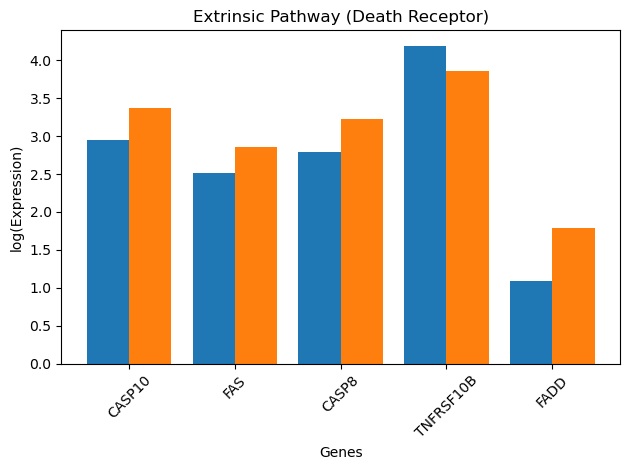

In [88]:
plot_category(extrinsic, "Extrinsic Pathway (Death Receptor)")


## Instrinsic pathway
Here Anti-apoptotic dominance
1. BCL2 / BCL2L1 (survival proteins) ↑   in cancer
2. BAX (pro-apoptotic) ↓                 in cancer


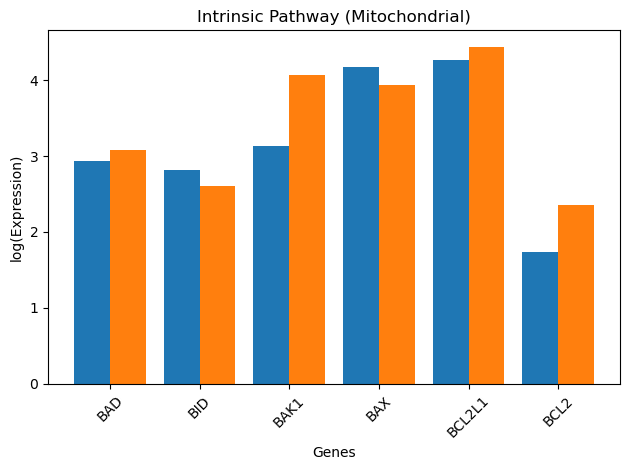

In [100]:

plot_category(intrinsic, "Intrinsic Pathway (Mitochondrial)")


## Mitochondrial Execution Control
All are high in tumor
means Apoptosome components exist but are not effectively triggered


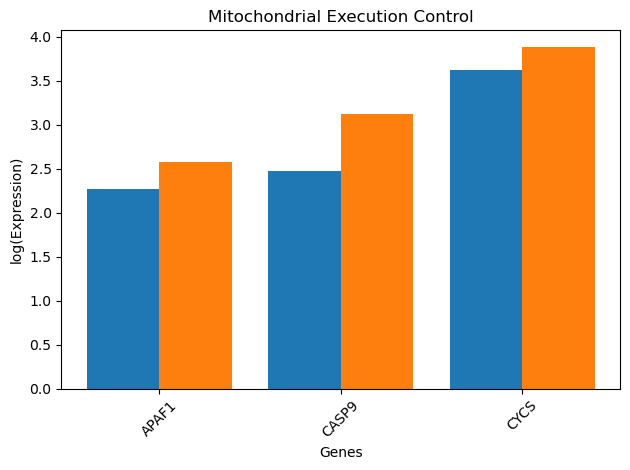

In [101]:

plot_category(mitochondrial_control, "Mitochondrial Execution Control")

## Executioner capcases

1. All ↑ in tumor
2. Apoptosis machinery exists but is functionally suppressed
3. later they were blocked by XIAP


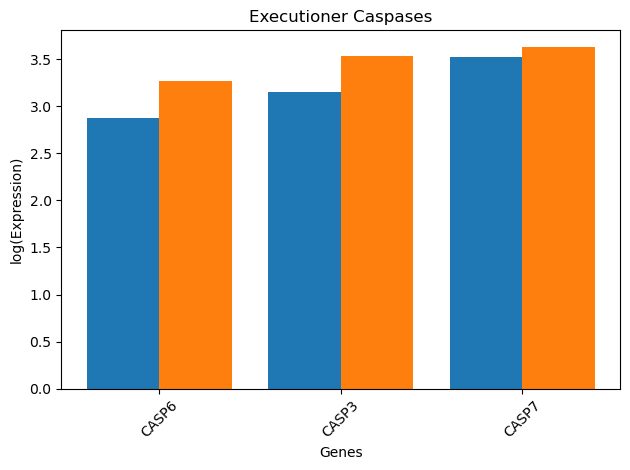

In [106]:

plot_category(executioner, "Executioner Caspases")


## 
Inhibitors & Regulators
1. Inhibitors & Regulators
2. DIABLO present
3. XIAP inhibits caspases → blocks apoptosis

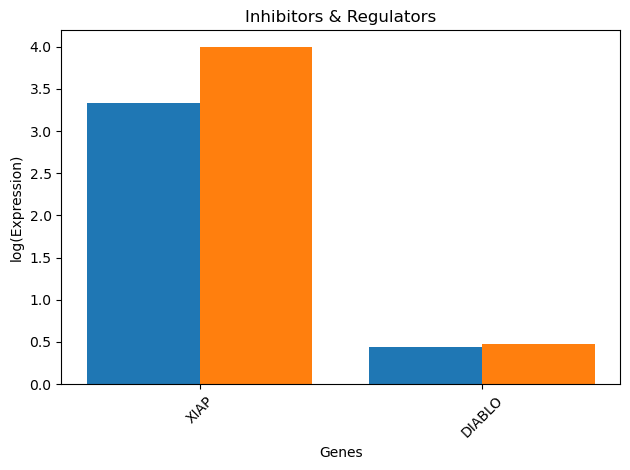

In [107]:

plot_category(inhibitors, "Inhibitors & Regulators")



## Tumor Suppressors & Cell Cycle
1. TP53 ↑
2. MDM2 ↑
3. ATM / ATR ↑
4. CDKN1A ↓ (very strong drop)
5. Stress response activated BUT cell cycle arrest fails

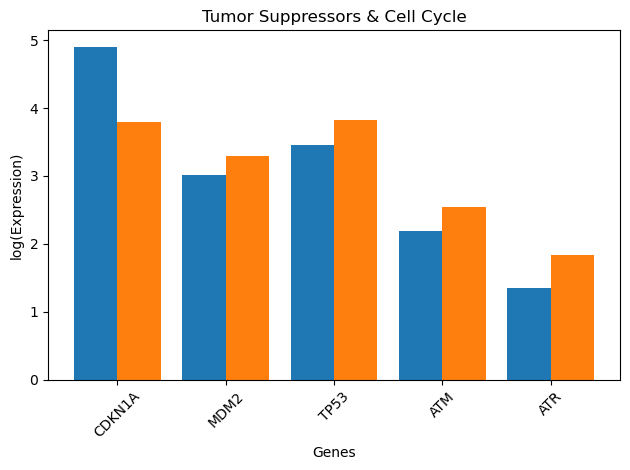

In [108]:

plot_category(tumor_regulators, "Tumor Suppressors & Cell Cycle")


## Survival / Crosstalk Pathways
Most are ↑ in tumor


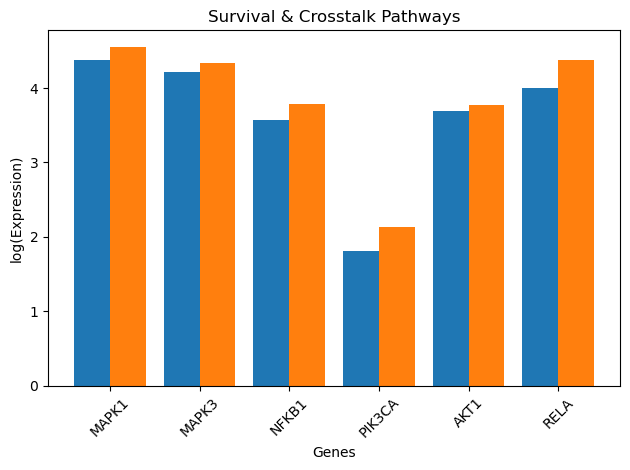

In [109]:

plot_category(survival, "Survival & Crosstalk Pathways")

## Tokken conversion